# SMITH whole-mouse-brain panel selection

This notebook runs a compact, deterministic version of the multi-objective panel-selection analysis underlying the whole-mouse-brain Results section. It creates an annotated expression object, trains the stochastic-gate selector on five objectives, and exports an eight-target ranking.

The compact input is designed for a runnable tutorial. It demonstrates the analysis path but does not claim to regenerate donor-level Figure 2 values.

[Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/wmb_section/01_SMITH_WMB_Panel_Selection_source.ipynb)

## Setup

Run this notebook from a cloned SMITH repository with `pip install -e '.[notebooks]'`. All inputs are checksum-validated before analysis.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repository(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside a SMITH repository checkout.")


ROOT = find_repository(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))

from smith.reproducibility import check_case, load_cases, run_case

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
print(f"Repository: {ROOT}")


Repository: /workspace/fanyimin/SMITH_package


In [2]:
CASE_ID = "01_wmb"
case = load_cases()[CASE_ID]
status = check_case(case)
if status["inputs"]:
    display(pd.DataFrame(status["inputs"])[["path", "exists", "sha256_ok"]])
else:
    print("This tutorial creates its deterministic input during execution.")
assert status["ready"], "The pinned tutorial inputs are missing or have changed."

output_dir = ROOT / "outputs" / "notebooks" / CASE_ID
result = run_case(case, output_dir)
print(f"Summary written to: {result['summary_json']}")
result


This tutorial creates its deterministic input during execution.


Wrote /workspace/fanyimin/SMITH_package/outputs/notebooks/01_wmb/example_panel.h5ad with shape 72 x 30


100%|██████████| 1/1 [00:00<00:00, 10.95it/s]


Epoch 0 Started
Task recon Loss - Train: 1.5206
Task cls Loss - Train: 1.1192
Task region Loss - Train: 0.6856
Task pathology Loss - Train: 0.7494
Task coo Loss - Train: 1.6881
Results saved: /workspace/fanyimin/SMITH_package/outputs/notebooks/01_wmb/logs/recon-cls-region-pathology-coordination-seed7-celltype.csv, /workspace/fanyimin/SMITH_package/outputs/notebooks/01_wmb/selection/epoch_0.csv


Summary written to: /workspace/fanyimin/SMITH_package/outputs/notebooks/01_wmb/summary.json


{'case': '01_wmb',
 'title': 'Whole mouse brain multi-objective panel selection',
 'manuscript_section': 'SMITH Balances Multiple Objectives in Whole Mouse Brain MERFISH Panel Design',
 'figure': 'Figure 2',
 'claim': 'A shared stochastic gate can produce a fixed-size target ranking under multiple biological objectives.',
 'selected_targets': ['GENE029',
  'GENE016',
  'GENE012',
  'GENE009',
  'GENE004',
  'GENE018',
  'GENE005',
  'GENE022'],
 'selected_panel_size': 8,
 'ranking_size': 30,
 'summary_json': '/workspace/fanyimin/SMITH_package/outputs/notebooks/01_wmb/summary.json'}

## Analysis

,target,rank_score
0,GENE029,8
1,GENE016,7
2,GENE012,6
3,GENE009,5
4,GENE004,4
5,GENE018,3
6,GENE005,2
7,GENE022,1


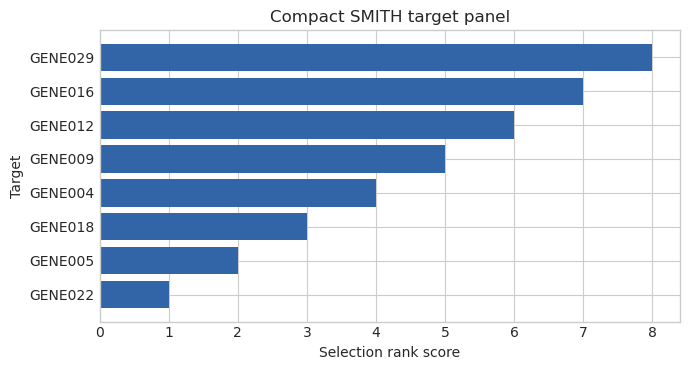

In [3]:
selected = pd.DataFrame({
    "target": result["selected_targets"],
    "rank_score": np.arange(result["selected_panel_size"], 0, -1),
})
display(selected)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(selected["target"][::-1], selected["rank_score"][::-1], color="#3264a8")
ax.set(xlabel="Selection rank score", ylabel="Target", title="Compact SMITH target panel")
fig.tight_layout()
plt.show()


## What this reproduces

This notebook reproduces the package path from annotated observations through multi-objective target ranking. The complete manuscript workflow additionally requires the WMB references, donor-aware splits, baseline panels, repeated seeds, transfer evaluation, ablations, and runtime benchmarking listed in `reproducibility/manifests/01_wmb.yaml`.